In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('churn.csv')
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [4]:
df.Churn.value_counts()

Churn
0    2655
1     495
Name: count, dtype: int64

<Axes: xlabel='Churn'>

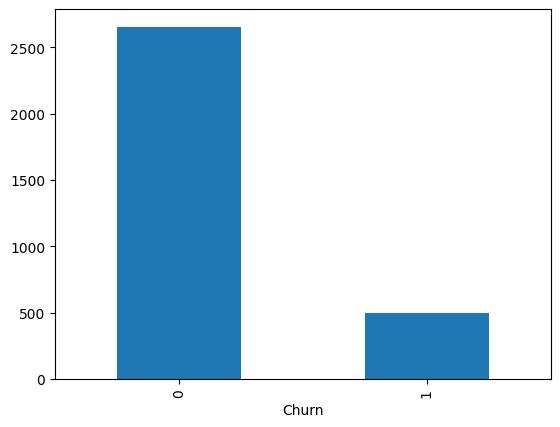

In [5]:
df.Churn.value_counts().plot(kind='bar')

In [6]:
df.isna().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [9]:
X=df.drop('Churn',axis=1)
y=df.Churn

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y, random_state=42)
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))
model.score(X_test,y_test)


              precision    recall  f1-score   support

           0       0.86      0.97      0.91       531
           1       0.49      0.17      0.25        99

    accuracy                           0.84       630
   macro avg       0.67      0.57      0.58       630
weighted avg       0.80      0.84      0.81       630



c:\Office_Data\Prsonal data\Prsonal data\Resume\myrepo\GenAIAndMachineLearningProjects\PracticeCode\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8412698412698413

In [10]:
y_train.value_counts()

Churn
0    2124
1     396
Name: count, dtype: int64

In [13]:
from imblearn.under_sampling import     RandomUnderSampler

rus=RandomUnderSampler(random_state=42)


X_train_rus,y_train_rus=rus.fit_resample(X_train,y_train)

y_train_rus.value_counts()

Churn
0    396
1    396
Name: count, dtype: int64

In [14]:
model = LogisticRegression()
model.fit(X_train_rus, y_train_rus)
y_pred_rus = model.predict(X_test)
print(classification_report(y_test, y_pred_rus))

              precision    recall  f1-score   support

           0       0.95      0.72      0.82       531
           1       0.35      0.81      0.49        99

    accuracy                           0.73       630
   macro avg       0.65      0.76      0.65       630
weighted avg       0.86      0.73      0.77       630



c:\Office_Data\Prsonal data\Prsonal data\Resume\myrepo\GenAIAndMachineLearningProjects\PracticeCode\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

y_train_smote.value_counts()

Churn
0    2124
1    2124
Name: count, dtype: int64

In [16]:
model =LogisticRegression()
model.fit(X_train_smote, y_train_smote)
y_pred_smote = model.predict(X_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.96      0.75      0.84       531
           1       0.39      0.84      0.53        99

    accuracy                           0.77       630
   macro avg       0.67      0.80      0.69       630
weighted avg       0.87      0.77      0.80       630



c:\Office_Data\Prsonal data\Prsonal data\Resume\myrepo\GenAIAndMachineLearningProjects\PracticeCode\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
from imblearn.combine import SMOTETomek
smt=SMOTETomek(random_state=42)
X_train_smt,y_train_smt=smt.fit_resample(X_train,y_train)
y_train_smt.value_counts()

Churn
0    2091
1    2091
Name: count, dtype: int64

In [19]:
model =LogisticRegression()
model.fit(X_train_smt,y_train_smt)
y_pred_smt = model.predict(X_test)
print(classification_report(y_test, y_pred_smt))

              precision    recall  f1-score   support

           0       0.96      0.76      0.85       531
           1       0.40      0.85      0.55        99

    accuracy                           0.78       630
   macro avg       0.68      0.81      0.70       630
weighted avg       0.88      0.78      0.80       630



c:\Office_Data\Prsonal data\Prsonal data\Resume\myrepo\GenAIAndMachineLearningProjects\PracticeCode\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
